# BSD35k-CS Classifier Confidence Analysis

BSD10k로 학습된 baseline `both` 5-fold classifier ensemble이 BSD35k-CS label을 어떻게 보는지 분석합니다.

핵심 컬럼:
- `provided_class`: BSD35k-CS metadata label
- `predicted_class`: BSD10k classifier ensemble prediction
- `classifier_confidence`: ensemble 평균 확률의 max probability
- `provided_class_probability`: BSD35k 제공 label에 할당된 확률
- `same_class`: 제공 label과 예측 label이 같은지
- `same_top_class`: top-level이 같은지


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
SCORE_DIR = ROOT / 'experiments' / 'bsd35k_scoring'
scores = pd.read_csv(SCORE_DIR / 'BSD35k-CS_classifier_scores.csv')
by_class = pd.read_csv(SCORE_DIR / 'BSD35k_classifier_scores_by_class.csv')
by_uploader = pd.read_csv(SCORE_DIR / 'BSD35k_classifier_scores_by_uploader.csv')

len(scores), scores.columns[:15].tolist()

(31464,
 ['sound_id',
  'class',
  'class_idx',
  'class_top',
  'confidence',
  'uploader',
  'license',
  'title',
  'tags',
  'description',
  'provided_class',
  'provided_top_class',
  'predicted_class',
  'predicted_top_class',
  'classifier_confidence'])

In [2]:
summary = {
    'rows': len(scores),
    'same_class_rate': scores['same_class'].mean(),
    'same_top_class_rate': scores['same_top_class'].mean(),
    'mean_classifier_confidence': scores['classifier_confidence'].mean(),
    'mean_provided_class_probability': scores['provided_class_probability'].mean(),
}
pd.Series(summary)

rows                               31464.000000
same_class_rate                        0.570175
same_top_class_rate                    0.751398
mean_classifier_confidence             0.764144
mean_provided_class_probability        0.505910
dtype: float64

## Confidence 분포

`classifier_confidence`는 모델이 선택한 class에 대한 확률이고, `provided_class_probability`는 BSD35k metadata label에 모델이 준 확률입니다. noisy label 후보는 대체로 `provided_class_probability`가 낮고 `classifier_confidence`가 높은 쪽에 몰립니다.

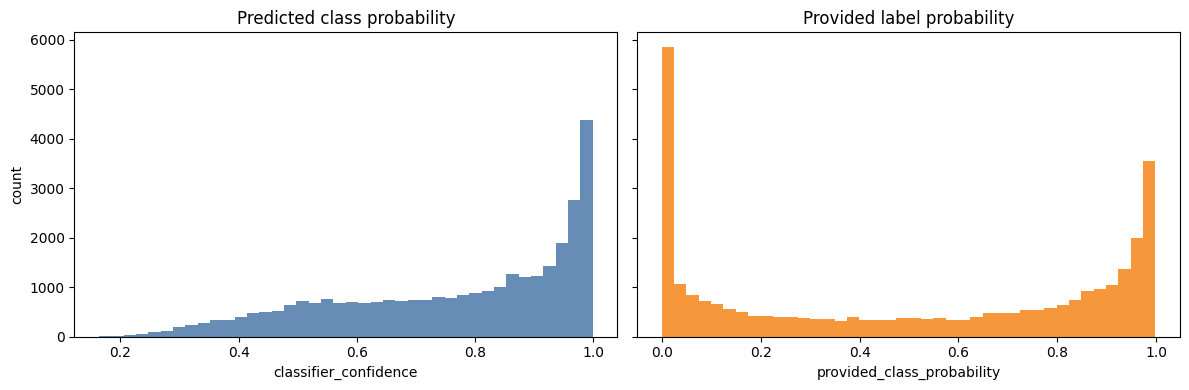

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(scores['classifier_confidence'], bins=40, color='#4C78A8', alpha=0.85)
axes[0].set_title('Predicted class probability')
axes[0].set_xlabel('classifier_confidence')
axes[0].set_ylabel('count')

axes[1].hist(scores['provided_class_probability'], bins=40, color='#F58518', alpha=0.85)
axes[1].set_title('Provided label probability')
axes[1].set_xlabel('provided_class_probability')
plt.tight_layout()

## Class별 label agreement

`same_class_rate`가 낮은 class는 BSD35k label noise가 많거나, BSD10k와 BSD35k domain shift가 큰 class입니다. 둘 다 대회 성능에 중요합니다.

In [4]:
display(by_class.sort_values('same_class_rate').head(12))
display(by_class.sort_values('same_class_rate', ascending=False).head(12))

,provided_top_class,provided_class,n,same_class_rate,same_top_class_rate,mean_classifier_confidence,mean_provided_class_probability,mean_ensemble_disagreement
0,fx,fx-m,1542,0.242542,0.933204,0.782944,0.217654,0.016737
1,is,is-p,2321,0.244722,0.312796,0.761920,0.224207,0.015435
2,ss,ss-i,383,0.248042,0.446475,0.677734,0.211124,0.020416
3,is,is-k,43,0.279070,0.534884,0.661856,0.271494,0.023598
4,sp,sp-c,50,0.320000,0.540000,0.668447,0.271971,0.020690
5,fx,fx-ex,839,0.336114,0.601907,0.619040,0.280092,0.025919
6,fx,fx-el,2000,0.348500,0.774000,0.635987,0.319176,0.026871
7,m,m-sp,964,0.375519,0.452282,0.842664,0.358798,0.011448
8,is,is-s,293,0.409556,0.723549,0.738808,0.422553,0.020268
9,is,is-w,34,0.411765,0.411765,0.759847,0.393045,0.016891


,provided_top_class,provided_class,n,same_class_rate,same_top_class_rate,mean_classifier_confidence,mean_provided_class_probability,mean_ensemble_disagreement
22,fx,fx-v,1852,0.832613,0.948704,0.745375,0.676631,0.016085
21,m,m-m,2044,0.783268,0.918787,0.757209,0.655757,0.015703
20,fx,fx-o,4534,0.776798,0.953683,0.844153,0.721891,0.012572
19,sp,sp-s,980,0.698980,0.772449,0.830823,0.648591,0.012779
18,fx,fx-n,659,0.684370,0.930197,0.786959,0.604399,0.016001
17,ss,ss-n,4831,0.680397,0.731319,0.739594,0.573679,0.016113
16,m,m-si,1344,0.642857,0.718750,0.869937,0.598312,0.009584
15,is,is-e,1360,0.627206,0.763235,0.746161,0.541688,0.018967
14,fx,fx-h,1423,0.536894,0.917779,0.818896,0.488959,0.014263
13,fx,fx-a,730,0.501370,0.784932,0.675895,0.426197,0.023499


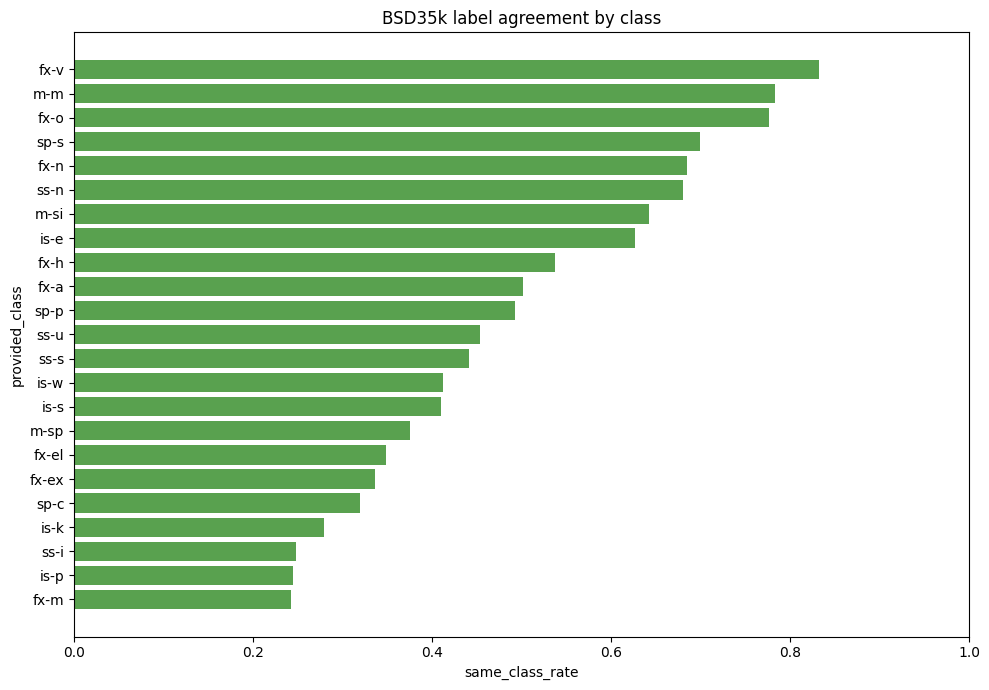

In [5]:
plot_df = by_class.sort_values('same_class_rate')
plt.figure(figsize=(10, 7))
plt.barh(plot_df['provided_class'], plot_df['same_class_rate'], color='#59A14F')
plt.xlabel('same_class_rate')
plt.ylabel('provided_class')
plt.title('BSD35k label agreement by class')
plt.xlim(0, 1)
plt.tight_layout()

## Top-level mismatch 후보

대회 metric은 hierarchy를 보기 때문에, second-level만 틀린 샘플보다 top-level까지 다른 샘플이 더 위험합니다.

In [6]:
top_mismatch = scores[~scores['same_top_class']].copy()
top_mismatch[['sound_id','provided_class','predicted_class','classifier_confidence','provided_class_probability','uploader','title','tags']].sort_values(
    ['classifier_confidence','provided_class_probability'], ascending=[False, True]
).head(30)

,sound_id,provided_class,predicted_class,classifier_confidence,provided_class_probability,uploader,title,tags
3188,802034,m-si,is-p,0.998801,0.000006,CVLTIV8R,Vintage Custom 14 inch Hi Hat-027.wav,"Custom,Cymbal,Cymbals,Drum,Drums,Hat,Hats,HiHa..."
3168,802014,m-si,is-p,0.998607,0.000009,CVLTIV8R,Vintage Custom 14 inch Hi Hat-007.wav,"Custom,Cymbal,Cymbals,Drum,Drums,Hat,Hats,HiHa..."
8694,809715,m-sp,is-p,0.998557,0.000245,CVLTIV8R,Snare Processed - Oneshot 4 - 14 by 6.5 inch B...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."
8641,809656,m-sp,is-p,0.998435,0.000255,CVLTIV8R,Snare Processed - Oneshot 2 - 14 by 6.5 inch B...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."
3153,801999,m-si,is-p,0.998365,0.000014,CVLTIV8R,Sabian 15 inch Custom Crash-17.wav,"15inch,Crash,Custom,Cymbal,Cymbals,Drum,Drums,..."
8703,809726,m-sp,is-p,0.998324,0.000335,CVLTIV8R,Snare Processed - Oneshot 5 - 14 by 6.5 inch B...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."
8486,809477,m-sp,is-p,0.998312,0.000405,CVLTIV8R,Med-low Tom - Oneshot 32 12 inch Sonor Force 3...,"acoustic,beat,drum,drumkit,drums,flam,kit,loop..."
8716,809740,m-sp,is-p,0.998240,0.000375,CVLTIV8R,Snare Processed - Oneshot 62 - 14 by 6.5 inch ...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."
8683,809704,m-sp,is-p,0.998219,0.000296,CVLTIV8R,Snare Processed - Oneshot 3 - 14 by 6.5 inch B...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."
8717,809741,m-sp,is-p,0.998198,0.000343,CVLTIV8R,Snare Processed - Oneshot 63 - 14 by 6.5 inch ...,"acoustic,beat,brass,crack,drum,drumkit,drums,f..."


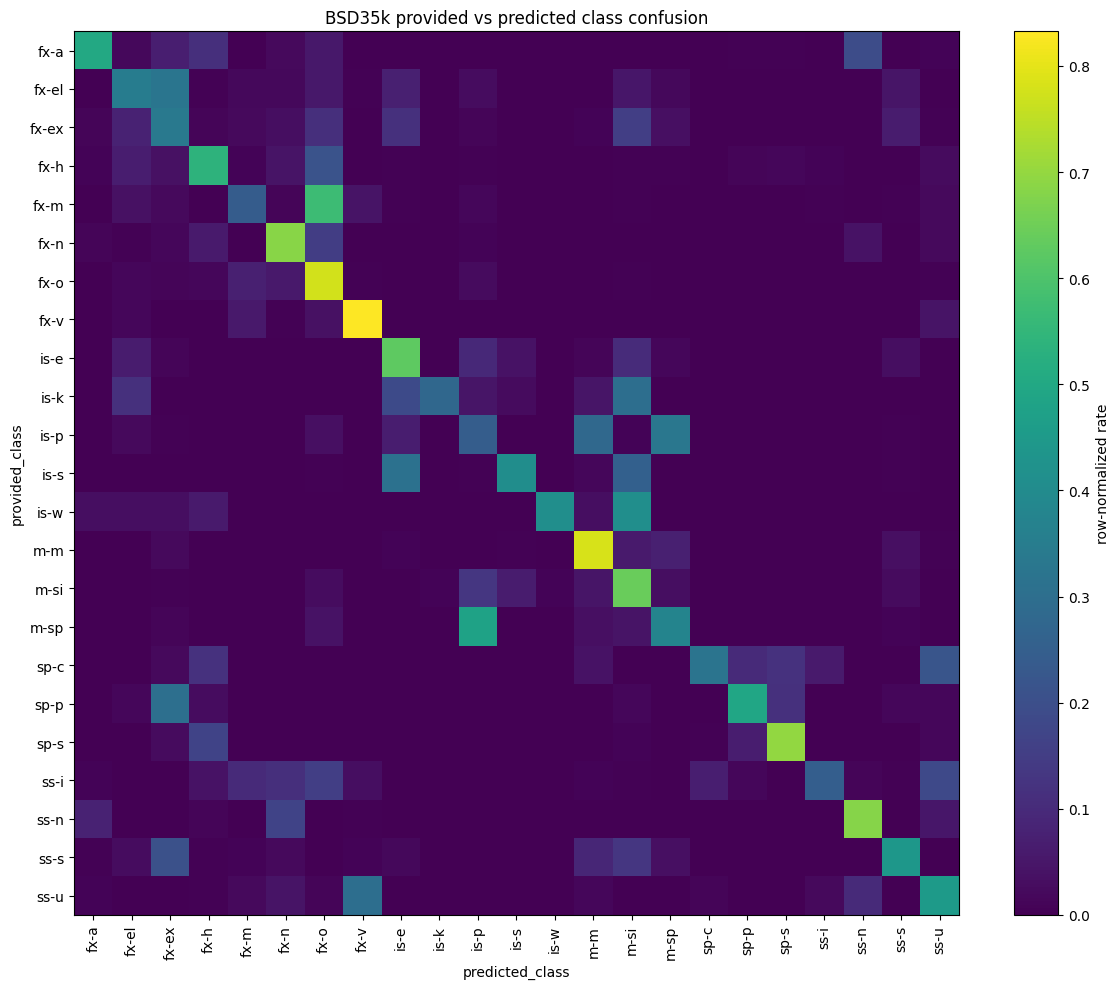

In [7]:
confusion = pd.crosstab(scores['provided_class'], scores['predicted_class'], normalize='index')
plt.figure(figsize=(12, 10))
plt.imshow(confusion.values, aspect='auto', cmap='viridis')
plt.colorbar(label='row-normalized rate')
plt.xticks(range(len(confusion.columns)), confusion.columns, rotation=90)
plt.yticks(range(len(confusion.index)), confusion.index)
plt.xlabel('predicted_class')
plt.ylabel('provided_class')
plt.title('BSD35k provided vs predicted class confusion')
plt.tight_layout()

## Uploader별 위험도

sample 수가 충분한 uploader 중 `same_class_rate`가 낮고 `provided_class_probability`가 낮은 uploader는 필터링 또는 down-weighting 후보입니다.

,uploader,n,same_class_rate,same_top_class_rate,mean_classifier_confidence,mean_provided_class_probability,dominant_class
0,Moulaythami,86,0.0,1.000000,0.951991,0.000164,fx-h
1,juhon,44,0.0,0.000000,0.783056,0.146290,ss-u
2,ristodromberg,44,0.0,0.000000,0.851208,0.094340,ss-u
3,naved_fardeen_khan,40,0.0,0.000000,0.871477,0.097957,ss-u
4,matias1111111,39,0.0,0.000000,0.805259,0.162108,ss-u
5,LauriT321,37,0.0,0.000000,0.861478,0.095391,ss-u
6,Leevij,37,0.0,0.000000,0.755149,0.145418,ss-u
7,oonailona,36,0.0,0.000000,0.817055,0.162216,ss-u
8,MichelleLMM,34,0.0,0.000000,0.844456,0.113254,ss-u
9,lematt,34,0.0,1.000000,0.964735,0.000553,fx-ex


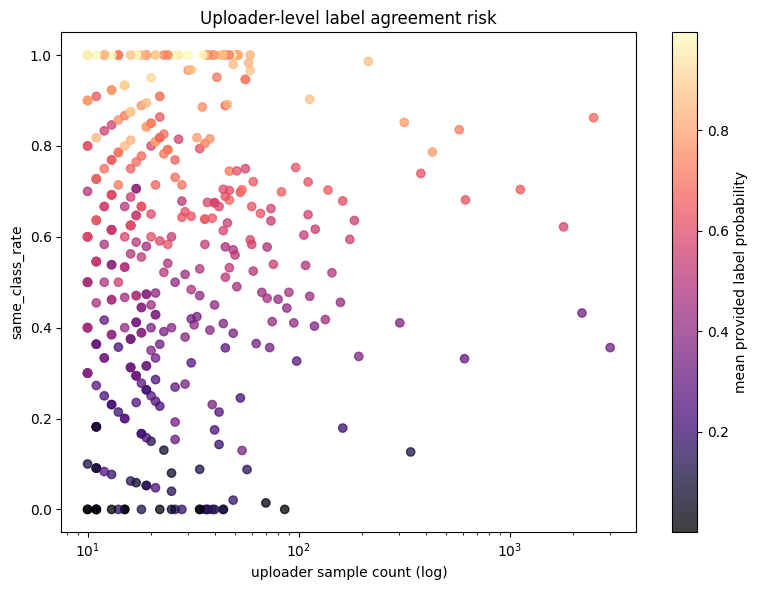

In [8]:
u = by_uploader[by_uploader['n'] >= 10].copy()

u['exact_mismatch_count'] = (u['n'] * (1 - u['same_class_rate'])).round().astype(int)
u['top_mismatch_count'] = (u['n'] * (1 - u['same_top_class_rate'])).round().astype(int)

uploader_cols = [
    'uploader',
    'n',
    'exact_mismatch_count',
    'top_mismatch_count',
    'same_class_rate',
    'same_top_class_rate',
    'mean_classifier_confidence',
    'mean_provided_class_probability',
    'dominant_class',
]

rate_risk = u.sort_values(['same_class_rate', 'mean_provided_class_probability']).head(25)
impact_risk = u.sort_values(['top_mismatch_count', 'exact_mismatch_count'], ascending=False).head(30)

print('Rate-based risky uploaders: low same_class_rate among uploaders with n >= 10')
display(rate_risk[uploader_cols])

print('Impact-based risky uploaders: largest number of top-level mismatches')
display(impact_risk[uploader_cols])

plt.figure(figsize=(8, 6))
plt.scatter(
    u['n'],
    u['same_class_rate'],
    c=u['mean_provided_class_probability'],
    cmap='magma',
    alpha=0.75,
)
plt.xscale('log')
plt.colorbar(label='mean provided label probability')
plt.xlabel('uploader sample count (log)')
plt.ylabel('same_class_rate')
plt.title('Uploader-level mismatch rate risk')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(
    impact_risk['n'],
    impact_risk['top_mismatch_count'],
    c=impact_risk['mean_provided_class_probability'],
    s=impact_risk['mean_classifier_confidence'] * 250,
    cmap='magma',
    alpha=0.8,
)
for _, r in impact_risk.head(10).iterrows():
    plt.text(r['n'], r['top_mismatch_count'], r['uploader'], fontsize=9)
plt.xscale('log')
plt.colorbar(label='mean provided label probability')
plt.xlabel('uploader sample count (log)')
plt.ylabel('top-level mismatch count')
plt.title('Uploaders with the most top-level mismatches')
plt.tight_layout()

## Clean set 후보 threshold sweep

첫 실험용 clean BSD35k set은 `same_class=True`와 `provided_class_probability` threshold 조합으로 만들 수 있습니다.

,threshold,kept_n,kept_rate,classes_present,min_class_count
0,0.10,17940,0.570175,23,12
1,0.15,17940,0.570175,23,12
2,0.20,17937,0.570080,23,12
3,0.25,17920,0.569540,23,12
4,0.30,17845,0.567156,23,12
5,0.35,17680,0.561912,23,11
6,0.40,17389,0.552663,23,11
7,0.45,16995,0.540141,23,10
8,0.50,16446,0.522693,23,10
9,0.55,15718,0.499555,23,8


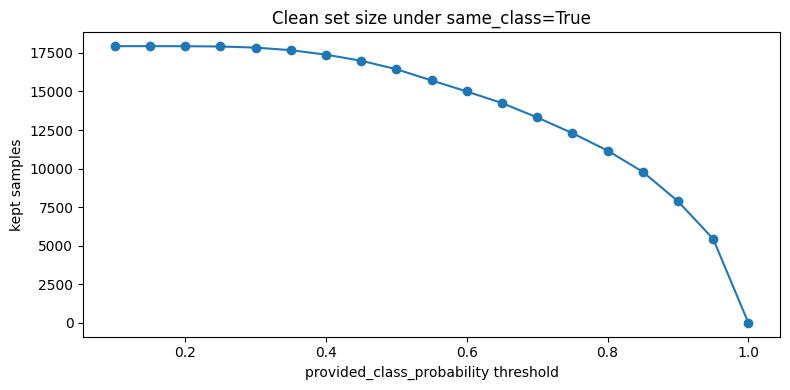

In [9]:
rows = []
for t in np.arange(0.1, 1.01, 0.05):
    keep = scores[(scores['same_class']) & (scores['provided_class_probability'] >= t)]
    rows.append({
        'threshold': round(float(t), 2),
        'kept_n': len(keep),
        'kept_rate': len(keep) / len(scores),
        'classes_present': keep['provided_class'].nunique(),
        'min_class_count': int(keep['provided_class'].value_counts().min()) if len(keep) else 0,
    })
sweep = pd.DataFrame(rows)
display(sweep)

plt.figure(figsize=(8, 4))
plt.plot(sweep['threshold'], sweep['kept_n'], marker='o')
plt.xlabel('provided_class_probability threshold')
plt.ylabel('kept samples')
plt.title('Clean set size under same_class=True')
plt.tight_layout()